In [2]:
"""
Notebook 07 - Comparaison Baseline vs V2
AnanthiX AI - Jalon 4
"""
import os, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/AnanthiX_AI'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Mounted at /content/drive
Device : cuda


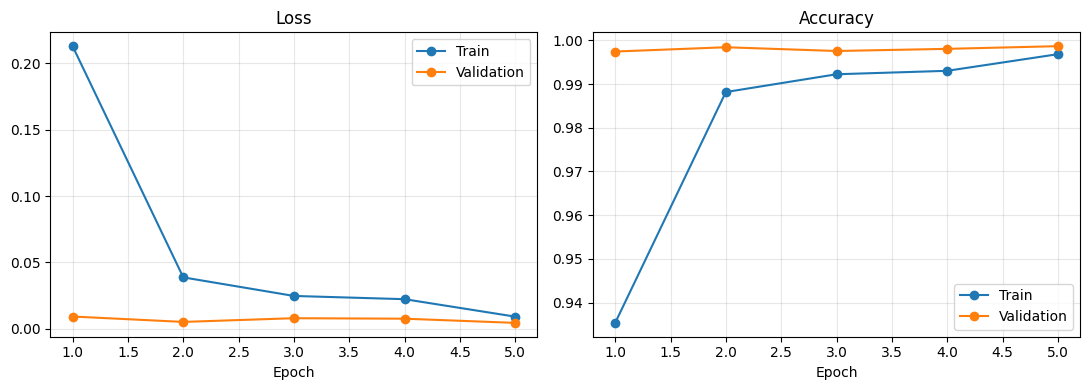

In [5]:
import json
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/AnanthiX_AI/results/training_history_v2.json') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs, history['val_loss'], label='Validation', marker='o')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='Train', marker='o')
axes[1].plot(epochs, history['val_acc'], label='Validation', marker='o')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
with open(f'{PROJECT_ROOT}/results/class_names.json') as f:
    class_names = json.load(f)

with open(f'{PROJECT_ROOT}/results/plantdoc_mapping.json') as f:
    plantdoc_to_my_class = json.load(f)

class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES = len(class_names)
print(f" {NUM_CLASSES} classes")

 38 classes


In [ ]:
def load_resnet50_with_weights(weights_path):
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    state = torch.load(weights_path, map_location=device)
    model.load_state_dict(state)
    model.eval().to(device)
    return model

baseline_path = f'{PROJECT_ROOT}/models/resnet50_baseline.pth'
v2_path = f'{PROJECT_ROOT}/models/resnet50_v2.pth'

print(" Chargement baseline...")
baseline = load_resnet50_with_weights(baseline_path)
print(" Chargement v2...")
v2 = load_resnet50_with_weights(v2_path)
print(" Les deux modèles sont chargés")

 Chargement baseline...
 Chargement v2...
 Les deux modèles sont chargés


In [ ]:
PLANTDOC_DIR = '/content/plantdoc'

if not os.path.exists(f'{PLANTDOC_DIR}/test'):
    print(" Re-téléchargement PlantDoc...")
    !mkdir -p ~/.kaggle && cp /content/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !mkdir -p {PLANTDOC_DIR}
    !kaggle datasets download -d nirmalsankalana/plantdoc-dataset -p {PLANTDOC_DIR} --unzip -q
    print(" PlantDoc prêt")
else:
    print(" PlantDoc déjà présent")

 Re-téléchargement PlantDoc...
cp: cannot stat '/content/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset
License(s): CC0-1.0
 PlantDoc prêt


In [ ]:
IMG_SIZE = 256

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class PlantDocTestDataset(Dataset):
    def __init__(self, root_dir, mapping, class_to_idx, transform):
        self.samples = []  # liste de (path, label)
        for pd_class, my_class in mapping.items():
            class_dir = os.path.join(root_dir, pd_class)
            if not os.path.exists(class_dir):
                continue
            label = class_to_idx[my_class]
            for fname in os.listdir(class_dir):
                self.samples.append((os.path.join(class_dir, fname), label))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, lbl = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), lbl

terrain_test = PlantDocTestDataset(
    root_dir=f'{PLANTDOC_DIR}/test',
    mapping=plantdoc_to_my_class,
    class_to_idx=class_to_idx,
    transform=eval_transform,
)
terrain_loader = DataLoader(terrain_test, batch_size=64, shuffle=False, num_workers=2)
print(f" Jeu de test terrain : {len(terrain_test)} images")

 Jeu de test terrain : 252 images


In [ ]:
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split

print(" Chargement PlantVillage...")
ds, info = tfds.load('plant_village', split='train', as_supervised=True, with_info=True)

pv_images, pv_labels = [], []
for img, label in tqdm(tfds.as_numpy(ds), total=info.splits['train'].num_examples):
    img_pil = Image.fromarray(img).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    pv_images.append(np.array(img_pil, dtype=np.uint8))
    pv_labels.append(int(label))
pv_images = np.stack(pv_images)
pv_labels = np.array(pv_labels)

# Split identique au J2 (seed=42)
idx = np.arange(len(pv_labels))
idx_train, idx_temp, _, y_temp = train_test_split(
    idx, pv_labels, test_size=0.30, random_state=42, stratify=pv_labels
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print(f"PlantVillage test : {len(idx_test)} images")

class PVTestDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.transform(Image.fromarray(self.images[idx])), int(self.labels[idx])

lab_test = PVTestDataset(pv_images[idx_test], pv_labels[idx_test], eval_transform)
lab_loader = DataLoader(lab_test, batch_size=64, shuffle=False, num_workers=2)

 Chargement PlantVillage...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.9N6QYV_1.0.2/plant_village-train.tfrecord-[0-9][0…

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


100%|██████████| 54303/54303 [00:09<00:00, 5588.34it/s]


PlantVillage test : 8146 images


In [ ]:
@torch.no_grad()
def evaluate_model(model, loader, name=""):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, lbls in tqdm(loader, desc=f'Eval {name}'):
        imgs = imgs.to(device)
        out = model(imgs)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())
    return np.array(all_preds), np.array(all_labels)

In [ ]:
# Baseline
baseline_lab_preds, lab_labels = evaluate_model(baseline, lab_loader, "baseline-lab")
baseline_terrain_preds, terrain_labels = evaluate_model(baseline, terrain_loader, "baseline-terrain")

# V2
v2_lab_preds, _ = evaluate_model(v2, lab_loader, "v2-lab")
v2_terrain_preds, _ = evaluate_model(v2, terrain_loader, "v2-terrain")

print(" Toutes les évaluations terminées")

Eval v2-terrain: 100%|██████████| 4/4 [00:02<00:00,  1.90it/s]

 Toutes les évaluations terminées


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def all_metrics(preds, labels):
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
    }

metrics = {
    'baseline_lab':     all_metrics(baseline_lab_preds, lab_labels),
    'baseline_terrain': all_metrics(baseline_terrain_preds, terrain_labels),
    'v2_lab':           all_metrics(v2_lab_preds, lab_labels),
    'v2_terrain':       all_metrics(v2_terrain_preds, terrain_labels),
}

# Affichage
print(f"\n{'Métrique':<20s} {'Baseline-Lab':>14s} {'V2-Lab':>14s} {'Δ':>10s}  |  {'Baseline-Terrain':>18s} {'V2-Terrain':>14s} {'Δ':>10s}")
print("="*120)
for m in ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']:
    bl = metrics['baseline_lab'][m]
    v2l = metrics['v2_lab'][m]
    bt = metrics['baseline_terrain'][m]
    v2t = metrics['v2_terrain'][m]
    print(f"{m:<20s} {bl:>14.4f} {v2l:>14.4f} {(v2l-bl)*100:>+9.2f}%  |  {bt:>18.4f} {v2t:>14.4f} {(v2t-bt)*100:>+9.2f}%")


Métrique               Baseline-Lab         V2-Lab          Δ  |    Baseline-Terrain     V2-Terrain          Δ
accuracy                     0.9972         0.9977     +0.05%  |              0.2698         0.6984    +42.86%
f1_macro                     0.9964         0.9970     +0.07%  |              0.2063         0.6942    +48.79%
f1_weighted                  0.9972         0.9977     +0.05%  |              0.2703         0.6965    +42.63%
precision_macro              0.9968         0.9968     +0.00%  |              0.3123         0.7148    +40.25%
recall_macro                 0.9960         0.9973     +0.13%  |              0.2101         0.7008    +49.07%


In [ ]:
print("\n" + "="*70)
print(" TABLEAU RÉCAPITULATIF")

print(f"\n{'Métrique':<35s} {'Baseline':>12s} {'V2':>12s} {'Gain':>10s}")
print("-"*70)
print(f"{'Accuracy LAB (PlantVillage test)':<35s} {metrics['baseline_lab']['accuracy']*100:>11.2f}% {metrics['v2_lab']['accuracy']*100:>11.2f}% {(metrics['v2_lab']['accuracy']-metrics['baseline_lab']['accuracy'])*100:>+9.2f}pts")
print(f"{'Accuracy TERRAIN (PlantDoc test)':<35s} {metrics['baseline_terrain']['accuracy']*100:>11.2f}% {metrics['v2_terrain']['accuracy']*100:>11.2f}% {(metrics['v2_terrain']['accuracy']-metrics['baseline_terrain']['accuracy'])*100:>+9.2f}pts")
print(f"{'F1 macro LAB':<35s} {metrics['baseline_lab']['f1_macro']:>12.4f} {metrics['v2_lab']['f1_macro']:>12.4f} {metrics['v2_lab']['f1_macro']-metrics['baseline_lab']['f1_macro']:>+10.4f}")
print(f"{'F1 macro TERRAIN':<35s} {metrics['baseline_terrain']['f1_macro']:>12.4f} {metrics['v2_terrain']['f1_macro']:>12.4f} {metrics['v2_terrain']['f1_macro']-metrics['baseline_terrain']['f1_macro']:>+10.4f}")



 TABLEAU RÉCAPITULATIF

Métrique                                Baseline           V2       Gain
----------------------------------------------------------------------
Accuracy LAB (PlantVillage test)          99.72%       99.77%     +0.05pts
Accuracy TERRAIN (PlantDoc test)          26.98%       69.84%    +42.86pts
F1 macro LAB                              0.9964       0.9970    +0.0007
F1 macro TERRAIN                          0.2063       0.6942    +0.4879


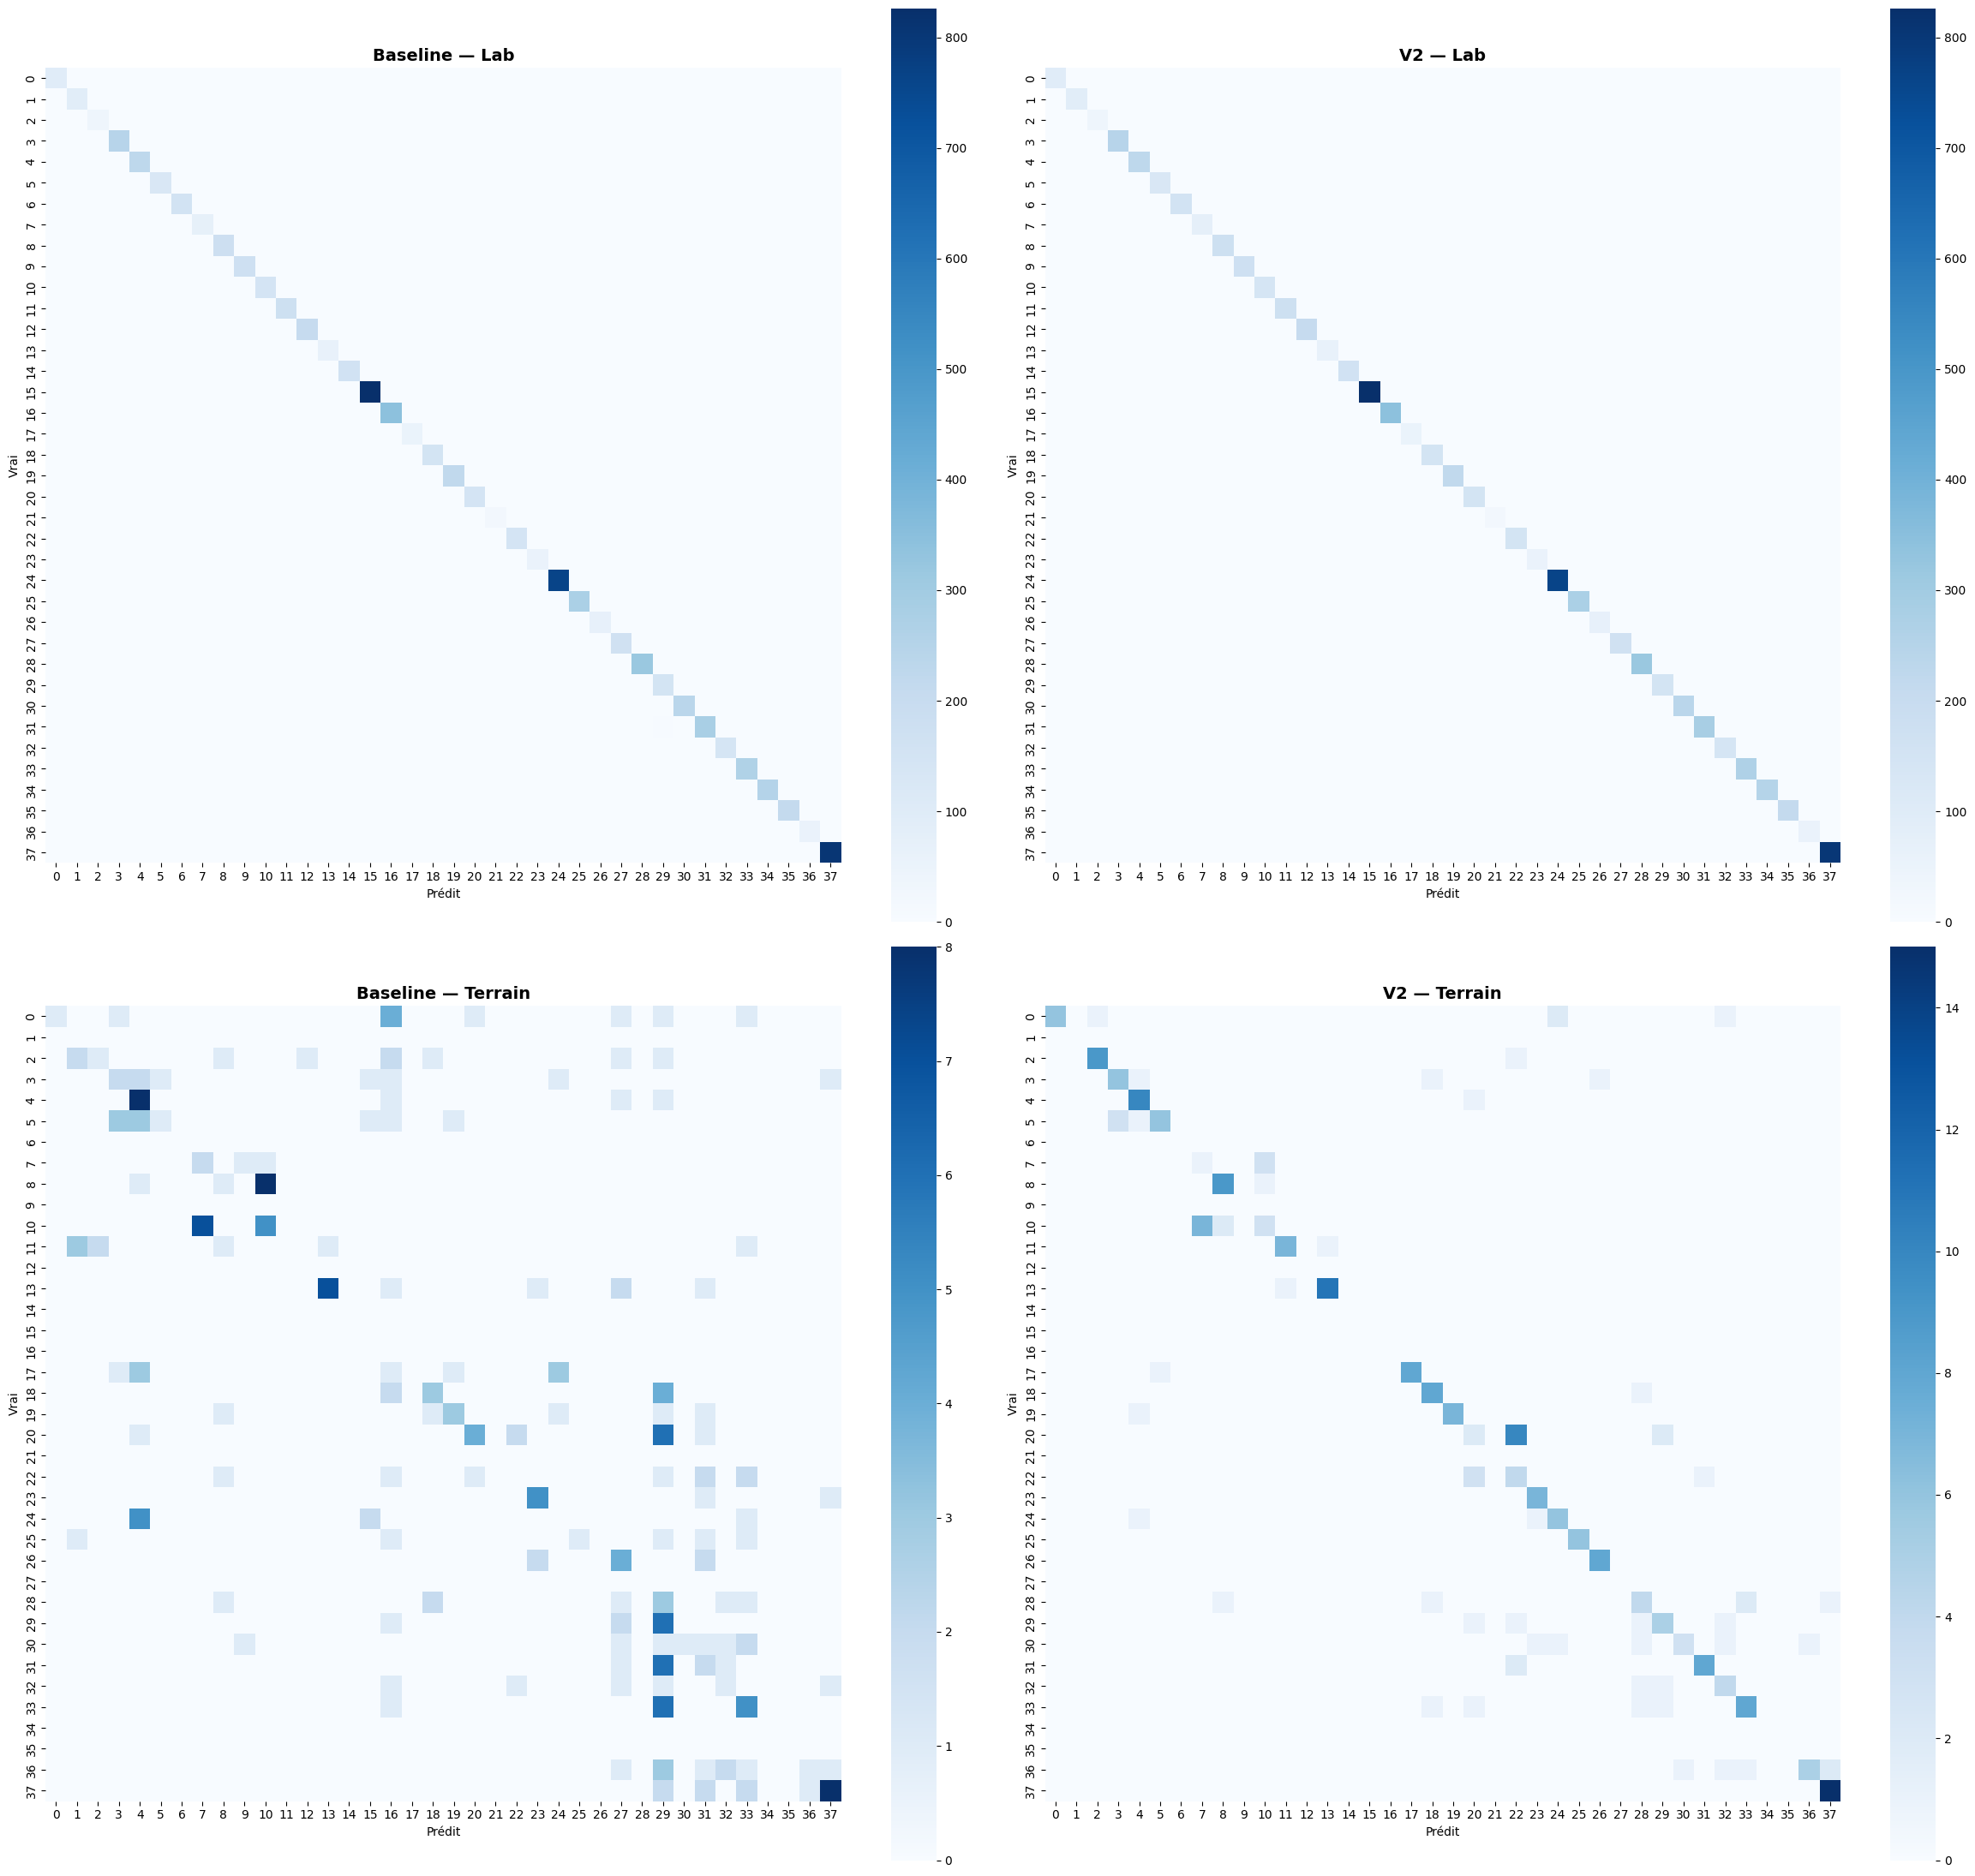

 Matrices sauvegardées : /content/drive/MyDrive/AnanthiX_AI/results/comparison_confusion_matrices.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(24, 22))

datasets = [
    ('Baseline — Lab', baseline_lab_preds, lab_labels, axes[0, 0]),
    ('V2 — Lab', v2_lab_preds, lab_labels, axes[0, 1]),
    ('Baseline — Terrain', baseline_terrain_preds, terrain_labels, axes[1, 0]),
    ('V2 — Terrain', v2_terrain_preds, terrain_labels, axes[1, 1]),
]

for title, preds, lbls, ax in datasets:
    cm = confusion_matrix(lbls, preds, labels=range(NUM_CLASSES))
    sns.heatmap(cm, annot=False, cmap='Blues', square=True, cbar=True, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Vrai')

plt.tight_layout()
output_path = f'{PROJECT_ROOT}/results/comparison_confusion_matrices.png'
plt.savefig(output_path, dpi=120, bbox_inches='tight')
plt.show()
print(f" Matrices sauvegardées : {output_path}")

In [ ]:
from sklearn.metrics import f1_score

# F1 par classe pour chaque combinaison
def f1_per_class(preds, labels):
    return f1_score(labels, preds, average=None, labels=range(NUM_CLASSES), zero_division=0)

baseline_f1_terrain = f1_per_class(baseline_terrain_preds, terrain_labels)
v2_f1_terrain = f1_per_class(v2_terrain_preds, terrain_labels)
baseline_f1_lab = f1_per_class(baseline_lab_preds, lab_labels)
v2_f1_lab = f1_per_class(v2_lab_preds, lab_labels)

# Tableau des classes avec gain/régression sur terrain
classes_with_terrain_data = set(plantdoc_to_my_class.values())

print(f"\n{'Idx':>3s}  {'Classe':<55s}  {'F1 baseline':>12s}  {'F1 v2':>10s}  {'Δ':>8s}  Terrain ?")
print("-" * 110)
for i, cn in enumerate(class_names):
    has_terrain = "✓" if cn in classes_with_terrain_data else " "
    delta = v2_f1_terrain[i] - baseline_f1_terrain[i]
    delta_str = f"{delta:+.3f}" if delta != 0 else "  0.000"
    print(f"{i:>3d}  {cn:<55s}  {baseline_f1_terrain[i]:>12.3f}  {v2_f1_terrain[i]:>10.3f}  {delta_str:>8s}  {has_terrain}")


Idx  Classe                                                    F1 baseline       F1 v2         Δ  Terrain ?
--------------------------------------------------------------------------------------------------------------
  0  Apple___Apple_scab                                              0.182       0.750    +0.568  ✓
  1  Apple___Black_rot                                               0.000       0.000     0.000   
  2  Apple___Cedar_apple_rust                                        0.154       0.900    +0.746  ✓
  3  Apple___healthy                                                 0.250       0.667    +0.417  ✓
  4  Blueberry___healthy                                             0.471       0.800    +0.329  ✓
  5  Cherry___healthy                                                0.167       0.706    +0.539  ✓
  6  Cherry___Powdery_mildew                                         0.000       0.000     0.000   
  7  Corn___Cercospora_leaf_spot Gray_leaf_spot                      0.308      

In [ ]:
# Tous les résultats dans un seul JSON pour le rapport
results = {
    'metrics': metrics,
    'per_class_f1_terrain': {
        'baseline': baseline_f1_terrain.tolist(),
        'v2': v2_f1_terrain.tolist(),
    },
    'per_class_f1_lab': {
        'baseline': baseline_f1_lab.tolist(),
        'v2': v2_f1_lab.tolist(),
    },
    'class_names': class_names,
    'test_sizes': {
        'lab': len(lab_labels),
        'terrain': len(terrain_labels),
    },
}

output_json = f'{PROJECT_ROOT}/results/comparison_baseline_v2.json'
with open(output_json, 'w') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f" Résultats sauvegardés : {output_json}")

 Résultats sauvegardés : /content/drive/MyDrive/AnanthiX_AI/results/comparison_baseline_v2.json
